In [2]:
import pandas as pd
import os
import glob

In [3]:
result = {}
for each in glob.glob(pathname='../images/*'):
    target = each.split('/')[-1]
    result[target] = glob.glob(pathname=os.path.abspath(f'{each}/*.jpg'))

In [4]:
count = {}
for key in result.keys():
    count[key] = len(result[key])
    
counts = pd.DataFrame([count]).T

<Axes: >

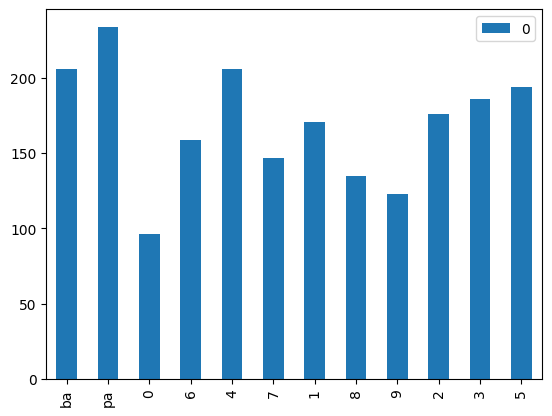

In [5]:
counts.plot(kind='bar')

---

## Lets work on Augumentation

In [6]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import save_image
from PIL import Image
from matplotlib import pyplot as plt

# im = Image.open("sample-image.png")

torch.manual_seed(17)


In [7]:
# This function will read the image using its path with opencv
def Load_Image(Path):
    img = Image.open(Path)
    return img

def Show_Image(Image, Picture_Name='picture'):
    plt.imshow(Image)
    plt.title(Picture_Name)
    plt.show()

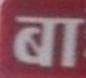

In [8]:
image1 = Load_Image(result['ba'][0])
image1

There are several transformation techniques used for augmentation in OCR (Optical Character Recognition) applications. Some of the most commonly used techniques include:

Rotation: This involves rotating the image to a certain degree, which can help the OCR algorithm to recognize characters that may be tilted or skewed.

Scaling: This technique involves increasing or decreasing the size of the image. Scaling can be useful when working with images that have characters of varying sizes.

Translation: This involves shifting the image horizontally or vertically. Translation can help the OCR algorithm to recognize characters that may be slightly off-center.

Shearing: This technique involves skewing the image horizontally or vertically. Shearing can help the OCR algorithm to recognize characters that may be slanted.

Noise addition: This involves adding random noise to the image, which can help the OCR algorithm to be more robust to noisy environments and low-quality images.

Contrast adjustment: This technique involves adjusting the contrast of the image, which can help the OCR algorithm to recognize characters that may be too light or too dark.

These techniques can be used individually or in combination to create a large number of variations of the same image, which can help to improve the accuracy and robustness of the OCR algorithm.

In [44]:
Horizontal_Flipping_Transformation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.CenterCrop(70),
    # transforms.RandomGrayscale(p=1),
    transforms.Resize((128, 128)),
    # transforms.ToTensor()
])
hr_flip_image = Horizontal_Flipping_Transformation(image1)

hr_flip_image = transforms.functional.to_grayscale(hr_flip_image)

hr_flip_image = transforms.ToTensor()(hr_flip_image)

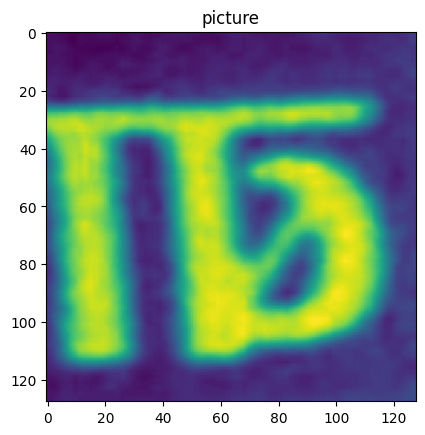

In [47]:
Show_Image(hr_flip_image.reshape(128,128))

In [21]:
import random
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path)

        if self.transform:
            # Randomly choose one of the specified transformations
            transformer = transforms.Compose(random.choice(self.transform))
            image = transformer(image)
            # images = transforms.Resize(128)(image)
            image = transforms.functional.to_grayscale(image)


        # Convert the image to a PyTorch tensor
        image = transforms.ToTensor()(image)

        return image

    def __len__(self):
        return len(self.image_paths)

# Define the image paths
image_paths = result['ba']

# Define the desired augmentation techniques for each image
transforms_list = [
    # [transforms.Resize((128, 128))],
    [transforms.Resize((128, 128)), transforms.RandomHorizontalFlip(p=0.5)],
    [transforms.Resize((128, 128)), transforms.RandomRotation(degrees=(30,45))],
    [transforms.Resize((128, 128)), transforms.ColorJitter(brightness=0.1, contrast=0.4, hue=0.2)],
]

# Create the dataset with the specified image paths and transformations
dataset = MyDataset(image_paths, transforms_list)

# Create a data loader to load the images in batches during training
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# # Train the model using the data loader
# for epoch in range(num_epochs):
#     for images in data_loader:
#         # Train the model on the batch of


In [ ]:
for each in data_loader:
    img_tensor = each
    break

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

# Assuming you have a tensor image 'img_tensor' with shape (batch_size, channels, height, width)
# Convert the tensor image to a grid of images
img_grid = vutils.make_grid(img_tensor, nrow=10, padding=2, normalize=True)

# Convert the grid to a numpy array and transpose it to (height, width, channels)
img_grid_np = np.transpose(img_grid.numpy(), (1, 2, 0))

# Display the image grid using Matplotlib
plt.figure(figsize=(15,10))
plt.imshow(img_grid_np)
plt.axis("off")
plt.show()
